# Sales Analytics Dashboard & Forecasting

This notebook analyzes company sales data to build a business dashboard and forecast future sales trends.

## Objectives
- Analyze historical sales performance
- Identify top-performing products and regions
- Monitor key sales KPIs
- Build dashboard-style visualizations
- Forecast future sales using time series models

## Tools Used
- Python
- Pandas
- Matplotlib / Seaborn
- Plotly
- Scikit-learn / Statsmodels

## Business Problem

Understanding sales trends is critical for strategic planning. This project analyzes historical sales data to identify performance patterns and predict future revenue.

Key business questions:
1. What are the overall sales trends?
2. Which products and regions generate the most revenue?
3. How do sales change over time?
4. Can we forecast future sales to support planning?

## Dataset Overview

The dataset contains transaction-level sales data. There are 3 tables

### Daily Sales Data per item

| Column | Description |
|------|-------------|
| Item | Name of item |
| Sales Rank  Quantity (Lunch / Dinner) | Rank of Quantity Sold |
| Sales Rank Amount (Lunch / Dinner) | Rank of Sales Amount |
| Sales Summary (Cash / PayNow) | Monetary Value of daily sales |


### Daily Sales Data per hour

| Column | Description |
|------|-------------|
| Time (per hour) | Starting time of the hour |
| Orders | Number of orders |
| Amount | Monetary Value of hourly sales |

### Monthly Sales Data

| Column | Description |
|------|-------------|
| Month/Year | Month and year |
| Rent | Cost of rent |
| Salary | Cost of employee salaries |
| CPF/Levy | Cost of employee CPF |
| Supplier | Cost of supplier |
| Utilities | Cost of utilities |
| Season Parking | Cost for parking |
| Total Sales | Business revenue |
| Profit/Loss | Net Profit or Loss |

Source: Koryori Hayashi

## Import Libraries

We import the required Python libraries for data processing, visualization, and forecasting.

In [39]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing


pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)
sns.set_theme(style='whitegrid')


## Load Dataset

The sales dataset is loaded into a Pandas DataFrame for analysis.

In [40]:
def find_data_xlsx() -> Path:
    candidates = [
        Path('data.xlsx'),
        Path('data') / 'data.xlsx',
        Path('..') / 'data' / 'data.xlsx',  
        Path('Dashboard') / 'data' / 'data.xlsx',
        Path('..') / 'Dashboard' / 'data' / 'data.xlsx',
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError('Could not find Dashboard/data/data.xlsx. Check your working directory.')


XLSX_PATH = find_data_xlsx()
XLSX_PATH


WindowsPath('C:/Users/65967/OneDrive - Singapore Management University/Documents/GitHub/Koryori_Hayashi/Dashboard/data/data.xlsx')

In [41]:
# Read the whole sheet as a raw grid (the 3 tables live side-by-side in the same sheet)
raw = pd.read_excel(XLSX_PATH, sheet_name=0, header=None)
raw.shape


(79, 20)

In [42]:
HEADER_ROW = 4  # row 5 in Excel (0-based index)

# Table 1: Daily Sales per item (A:D)
items = raw.iloc[HEADER_ROW:, 0:4].copy()
items.columns = raw.iloc[HEADER_ROW, 0:4].tolist()
items = items.iloc[1:].reset_index(drop=True)
items = items.dropna(subset=[items.columns[0]])

# Table 2: Daily Sales per hour (F:H)
hourly = raw.iloc[HEADER_ROW:, 5:8].copy()
hourly.columns = raw.iloc[HEADER_ROW, 5:8].tolist()
hourly = hourly.iloc[1:].reset_index(drop=True)
hourly = hourly.dropna(subset=[hourly.columns[0]])

# Table 3: Monthly Sales Data (J:R)
monthly = raw.iloc[HEADER_ROW:, 9:18].copy()
monthly.columns = raw.iloc[HEADER_ROW, 9:18].tolist()
monthly = monthly.iloc[1:].reset_index(drop=True)
monthly = monthly.dropna(subset=[monthly.columns[0]])

items.head(), hourly.head(), monthly.head()


(                        Item Sales Rank  Quantity (Lunch / Dinner) Sales Rank Amount (Lunch / Dinner)  \
 0         Chicken Nanban Don                                     1                                  2   
 1         Pork Shogayaki Don                                     2                                  1   
 2        Salmon Teriyaki Don                                     3                                  3   
 3  Salmon Belly Teriyaki Don                                     4                                  4   
 4       Chicken Teriyaki Don                                     5                                  5   
 
   Sales Summary (Cash / PayNow)  
 0                           420  
 1                           450  
 2                           400  
 3                           380  
 4                           360  ,
   Time (per hour) Orders  Amount
 0        11:00:00     12  149.27
 1        12:00:00     11  138.33
 2        13:00:00     11  146.28
 3        14:00

In [43]:
# Clean column names
monthly.columns = monthly.columns.str.strip()
hourly.columns = hourly.columns.str.strip()
items.columns = items.columns.str.strip()


## Feature Engineering

Additional features are created to support analysis and forecasting.

New variables include:
- Year
- Month
- Quarter
- Year-Month for time series analysis

In [44]:
# Some Excel exports label this column as 'Month / Year'. Normalize it.

monthly['Month'] = pd.to_datetime(monthly["Month / Year"], errors='coerce')
monthly = monthly.sort_values('Month').reset_index(drop=True)

monthly['Year'] = monthly['Month'].dt.year
monthly['MonthNum'] = monthly['Month'].dt.month
monthly['Quarter'] = monthly['Month'].dt.to_period('Q').astype(str)
monthly['YearMonth'] = monthly['Month'].dt.to_period('M').astype(str)

monthly[['Month', 'YearMonth', 'Year','MonthNum','Quarter','Total Sales', 'Profit / Loss']].head()


,Month,YearMonth,Year,MonthNum,Quarter,Total Sales,Profit / Loss
0,2025-01-01,2025-01,2025,1,2025Q1,3404,111.6
1,2025-02-01,2025-02,2025,2,2025Q1,2173.6,88.64
2,2025-03-01,2025-03,2025,3,2025Q1,3313.8,225.25
3,2025-04-01,2025-04,2025,4,2025Q2,1843,235.54
4,2025-05-01,2025-05,2025,5,2025Q2,1812.8,50.89


## Key Performance Indicators (KPIs)

Important metrics used to evaluate business performance:

- Total Revenue
- Total Orders
- Total Profit
- Average Order Value
- Total Units Sold

In [45]:
# Convert numeric columns to numeric types, coercing errors to NaN
for col in ['Total Sales', 'Profit / Loss']:
    if col in monthly.columns:
        monthly[col] = pd.to_numeric(monthly[col], errors='coerce')

for col in ['Orders', 'Amount']:
    if col in hourly.columns:
        hourly[col] = pd.to_numeric(hourly[col], errors='coerce')

if 'Sales Summary (Cash / PayNow)' in items.columns:
    items['Sales Summary (Cash / PayNow)'] = pd.to_numeric(
        items['Sales Summary (Cash / PayNow)'], errors='coerce'
    )

# Parse and sort monthly dates
monthly['Month'] = pd.to_datetime(monthly['Month / Year'], errors='coerce')
monthly = monthly.sort_values('Month').reset_index(drop=True)

monthly['Year'] = monthly['Month'].dt.year
monthly['MonthNum'] = monthly['Month'].dt.month
monthly['Quarter'] = monthly['Month'].dt.to_period('Q').astype(str)
monthly['YearMonth'] = monthly['Month'].dt.to_period('M').astype(str)

#Extract hour safely
hourly['Hour'] = hourly['Time (per hour)'].astype(str).str[:2]
hourly['Hour'] = pd.to_numeric(hourly['Hour'], errors='coerce')

#KPI calculations
total_sales_latest_month = (
    float(monthly['Total Sales'].iloc[-1])
    if len(monthly) and monthly['Total Sales'].notna().any()
    else 0.0
)

profit_latest_month = (
    float(monthly['Profit / Loss'].iloc[-1])
    if len(monthly) and monthly['Profit / Loss'].notna().any()
    else 0.0
)

margin_latest_month_pct = (
    profit_latest_month / total_sales_latest_month * 100
    if total_sales_latest_month
    else 0.0
)

total_orders_day = int(hourly['Orders'].sum()) if len(hourly) else 0
total_revenue_day = float(hourly['Amount'].sum()) if len(hourly) else 0.0
avg_order_value = total_revenue_day / total_orders_day if total_orders_day else 0.0

total_daily_item_sales = (
    float(items['Sales Summary (Cash / PayNow)'].sum())
    if len(items) and 'Sales Summary (Cash / PayNow)' in items.columns
    else 0.0
)

valid_hourly = hourly.dropna(subset=['Amount', 'Hour'])
peak_hour = (
    int(valid_hourly.loc[valid_hourly['Amount'].idxmax(), 'Hour'])
    if len(valid_hourly)
    else None
)

top_selling_item = (
    items.loc[items['Sales Summary (Cash / PayNow)'].idxmax(), 'Item']
    if len(items) and 'Sales Summary (Cash / PayNow)' in items.columns and items['Sales Summary (Cash / PayNow)'].notna().any()
    else None
)

top_item_sales = (
    float(items['Sales Summary (Cash / PayNow)'].max())
    if len(items) and 'Sales Summary (Cash / PayNow)' in items.columns
    else 0.0
)

# KPI output

kpis = {
    'Total Sales (Latest Month)': round(total_sales_latest_month, 2),
    'Profit/Loss (Latest Month)': round(profit_latest_month, 2),
    'Margin % (Latest Month)': round(margin_latest_month_pct, 2),
    'Orders (Today)': total_orders_day,
    'Revenue (Today)': round(total_revenue_day, 2),
    'Average Order Value': round(avg_order_value, 2),
    'Daily Sales Total (Items)': round(total_daily_item_sales, 2),
    'Peak Hour': f"{peak_hour}:00" if peak_hour is not None else None,
    'Top Selling Item': top_selling_item,
    'Top Item Sales': round(top_item_sales, 2),
}

kpi_series = pd.Series(kpis)
print(kpi_series)


Total Sales (Latest Month)                2544.4
Profit/Loss (Latest Month)                131.36
Margin % (Latest Month)                     5.16
Orders (Today)                                73
Revenue (Today)                           985.11
Average Order Value                        13.49
Daily Sales Total (Items)                 8013.0
Peak Hour                                  11:00
Top Selling Item              Pork Shogayaki Don
Top Item Sales                             450.0
dtype: object


## Exploratory Data Analysis

EDA helps understand patterns, distributions, and relationships within the sales data.

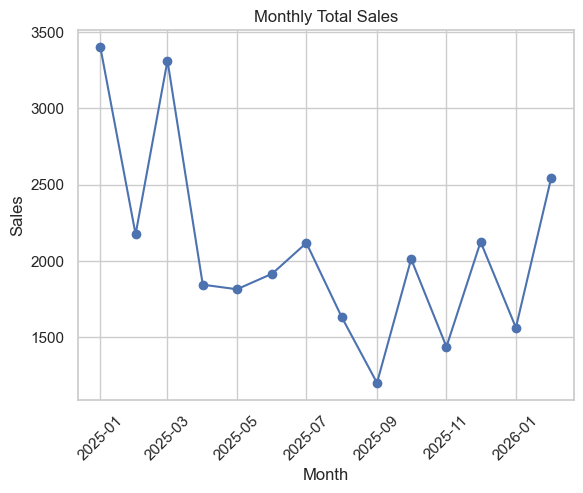

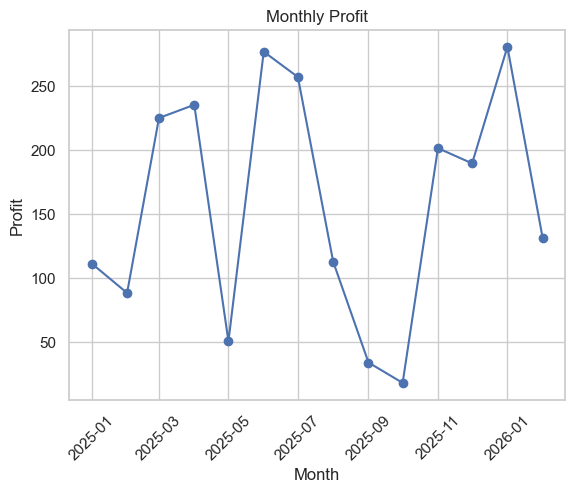

In [46]:
# Monthly Trends (Revenue & Profit

plt.figure()
plt.plot(monthly['Month'], monthly['Total Sales'], marker='o')
plt.title("Monthly Total Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

plt.figure()
plt.plot(monthly['Month'], monthly['Profit / Loss'], marker='o')
plt.title("Monthly Profit")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.show()

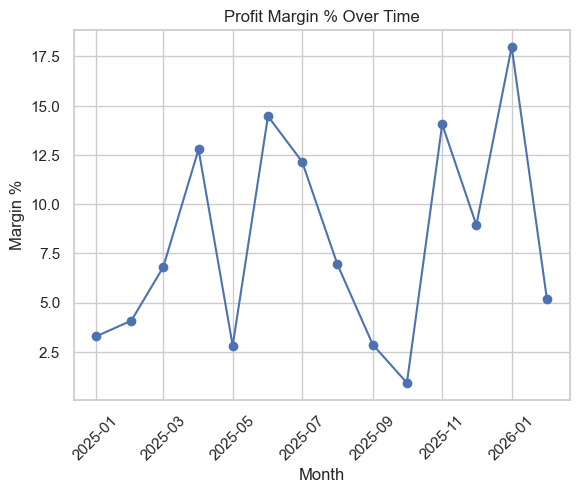

In [47]:
# Profit Margin Trend
monthly['Margin %'] = (monthly['Profit / Loss'] / monthly['Total Sales']) * 100

plt.figure()
plt.plot(monthly['Month'], monthly['Margin %'], marker='o')
plt.title("Profit Margin % Over Time")
plt.xlabel("Month")
plt.ylabel("Margin %")
plt.xticks(rotation=45)
plt.show()

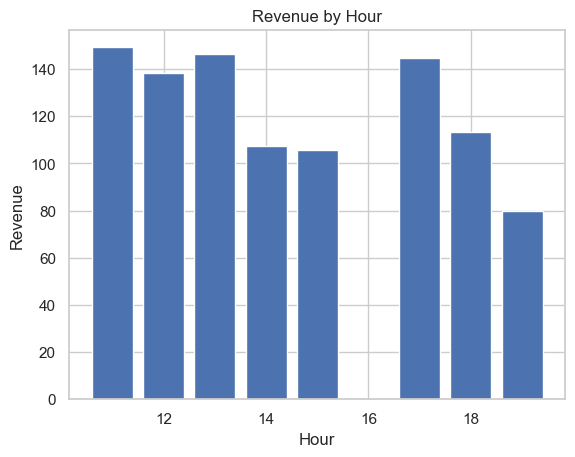

In [48]:
# Hourly Trends
plt.figure()
plt.bar(hourly['Hour'], hourly['Amount'])
plt.title("Revenue by Hour")
plt.xlabel("Hour")
plt.ylabel("Revenue")
plt.show()

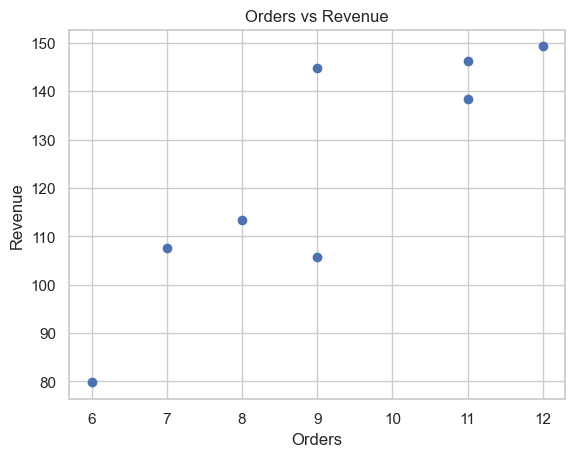

In [49]:
# Number of Orders vs Total Revenue
plt.figure()
plt.scatter(hourly['Orders'], hourly['Amount'])
plt.title("Orders vs Revenue")
plt.xlabel("Orders")
plt.ylabel("Revenue")
plt.show()

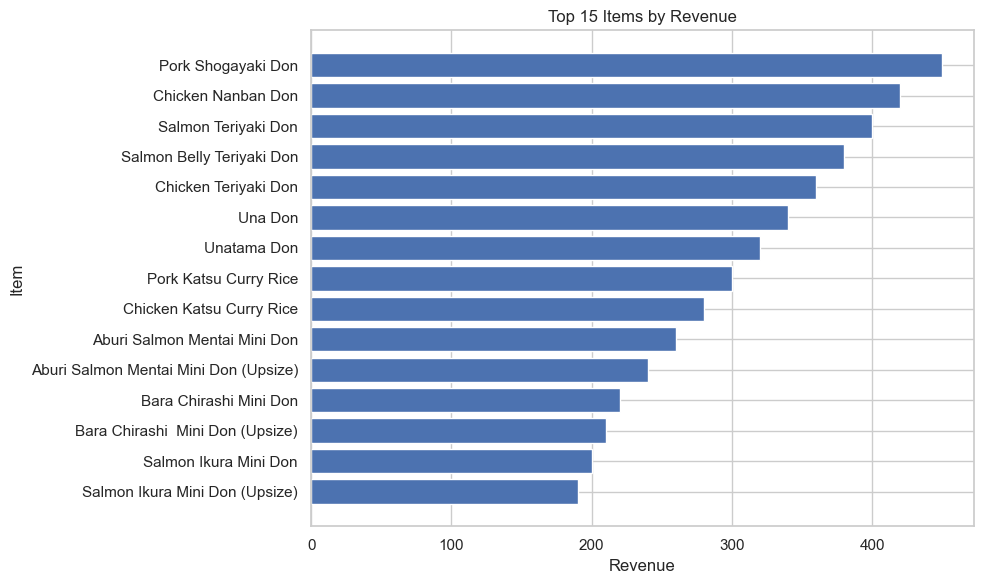

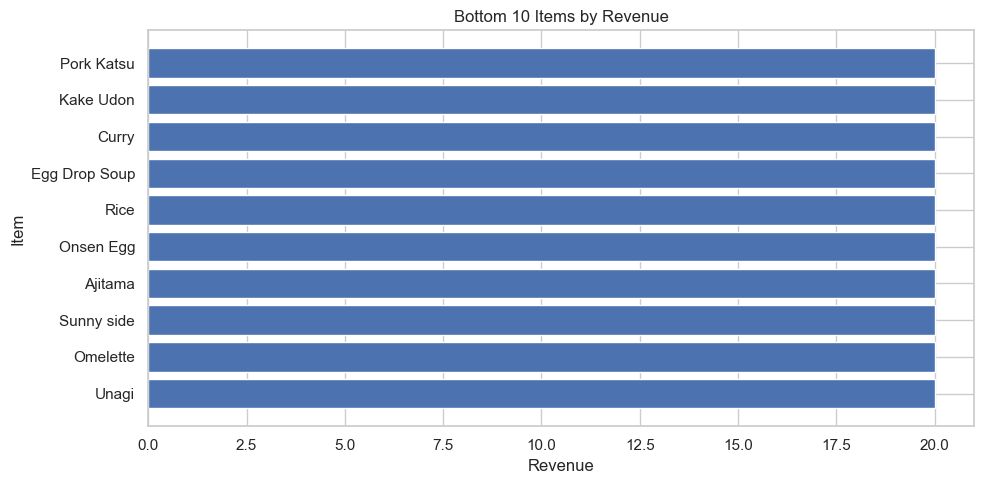

In [50]:
# Item Performance
top_n = 15

items_sorted = items.sort_values('Sales Summary (Cash / PayNow)', ascending=False).head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(items_sorted['Item'], items_sorted['Sales Summary (Cash / PayNow)'])
plt.title(f"Top {top_n} Items by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Item")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

bottom_n = 10

items_bottom = items.sort_values('Sales Summary (Cash / PayNow)', ascending=True).head(bottom_n)

plt.figure(figsize=(10, 5))
plt.barh(items_bottom['Item'], items_bottom['Sales Summary (Cash / PayNow)'])
plt.title(f"Bottom {bottom_n} Items by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Item")
plt.tight_layout()
plt.show()

In [51]:
# Top vs Bottom Items
top_5 = items_sorted.head(5)
bottom_5 = items_sorted.tail(5)

print("Top 5 Items:\n", top_5[['Item', 'Sales Summary (Cash / PayNow)']])
print("\nBottom 5 Items:\n", bottom_5[['Item', 'Sales Summary (Cash / PayNow)']])

Top 5 Items:
                         Item  Sales Summary (Cash / PayNow)
1         Pork Shogayaki Don                            450
0         Chicken Nanban Don                            420
2        Salmon Teriyaki Don                            400
3  Salmon Belly Teriyaki Don                            380
4       Chicken Teriyaki Don                            360

Bottom 5 Items:
                                      Item  Sales Summary (Cash / PayNow)
10  Aburi Salmon Mentai Mini Don (Upsize)                            240
11                 Bara Chirashi Mini Don                            220
12       Bara Chirashi  Mini Don (Upsize)                            210
13                  Salmon Ikura Mini Don                            200
14         Salmon Ikura Mini Don (Upsize)                            190


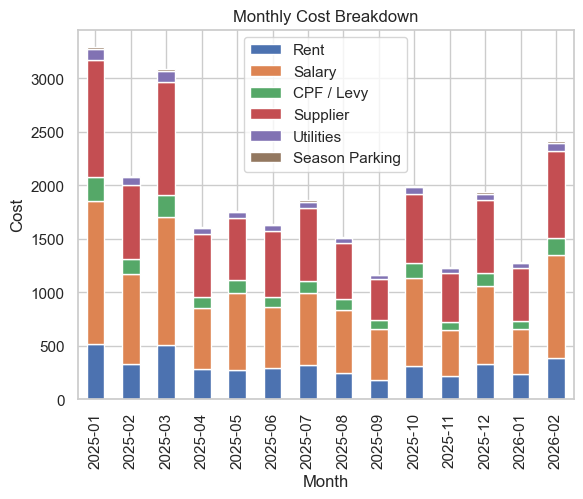

In [52]:
# Monthly Cost Breakdown
cost_cols = ['Rent', 'Salary', 'CPF / Levy', 'Supplier', 'Utilities', 'Season Parking']
monthly.set_index('YearMonth')[cost_cols].plot(kind='bar', stacked=True)

plt.title("Monthly Cost Breakdown")
plt.xlabel("Month")
plt.ylabel("Cost")
plt.show()

In [53]:
# Correlation Analysis
corr = monthly[['Total Sales', 'Profit / Loss'] + cost_cols].corr()
print(corr)

                Total Sales  Profit / Loss      Rent    Salary  CPF / Levy  Supplier  Utilities  Season Parking
Total Sales        1.000000       0.059601  1.000000  0.960301    0.960306  1.000000   0.996930        1.000000
Profit / Loss      0.059601       1.000000  0.059600 -0.221236   -0.221219  0.059599  -0.018745        0.059741
Rent               1.000000       0.059600  1.000000  0.960301    0.960306  1.000000   0.996930        1.000000
Salary             0.960301      -0.221236  0.960301  1.000000    1.000000  0.960301   0.979196        0.960261
CPF / Levy         0.960306      -0.221219  0.960306  1.000000    1.000000  0.960306   0.979200        0.960266
Supplier           1.000000       0.059599  1.000000  0.960301    0.960306  1.000000   0.996930        1.000000
Utilities          0.996930      -0.018745  0.996930  0.979196    0.979200  0.996930   1.000000        0.996918
Season Parking     1.000000       0.059741  1.000000  0.960261    0.960266  1.000000   0.996918        1

## Preparing Data for Forecasting

To forecast sales, the dataset is aggregated into monthly revenue values.

Time series forecasting requires:
- chronological order
- evenly spaced time intervals

In [54]:
# Build a clean monthly time series for forecasting

# 1) Select the target series (monthly Total Sales)
ts = monthly[['Month', 'Total Sales']].copy()
ts['Month'] = pd.to_datetime(ts['Month'], errors='coerce')
ts['Total Sales'] = pd.to_numeric(ts['Total Sales'], errors='coerce')
ts = ts.dropna(subset=['Month', 'Total Sales']).sort_values('Month')

# 2) Normalize to month-start and ensure a regular monthly frequency
ts['Month'] = ts['Month'].dt.to_period('M').dt.to_timestamp()  # month start
ts = ts.drop_duplicates(subset=['Month'], keep='last')

y = ts.set_index('Month')['Total Sales'].astype(float).asfreq('MS')
if y.isna().any():
    # If any months are missing, fill via interpolation to keep models stable
    y = y.interpolate(limit_direction='both')

print(f"Monthly observations: {len(y)}")
print(f"Range: {y.index.min().date()} -> {y.index.max().date()}")
display(y.head())
display(y.tail())

# 3) Train/test split (last N months as holdout)
if len(y) < 6:
    raise ValueError("Not enough monthly data to forecast reliably (need at least 6 months).")

TEST_MONTHS = 3 if len(y) >= 12 else max(1, len(y) // 5)
FORECAST_HORIZON = 6  # months to forecast into the future

train_y = y.iloc[:-TEST_MONTHS]
test_y = y.iloc[-TEST_MONTHS:]

print(f"Train months: {len(train_y)} | Test months: {len(test_y)} | Future months: {FORECAST_HORIZON}")

# 4) Helper: time features for regression models
def _make_time_features(month_index: pd.DatetimeIndex) -> pd.DataFrame:
    df = pd.DataFrame({'ds': month_index})
    df['t'] = np.arange(len(df), dtype=float)
    df['month'] = df['ds'].dt.month.astype(int)
    # simple yearly seasonality
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12.0)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12.0)
    return df.set_index('ds')

train_X = _make_time_features(train_y.index)
test_X = _make_time_features(test_y.index)

future_index = pd.date_range(start=y.index.max() + pd.offsets.MonthBegin(1), periods=FORECAST_HORIZON, freq='MS')
future_X = _make_time_features(future_index)


Monthly observations: 14
Range: 2025-01-01 -> 2026-02-01


Month
2025-01-01    3404.0
2025-02-01    2173.6
2025-03-01    3313.8
2025-04-01    1843.0
2025-05-01    1812.8
Freq: MS, Name: Total Sales, dtype: float64

Month
2025-10-01    2011.0
2025-11-01    1435.2
2025-12-01    2124.2
2026-01-01    1560.8
2026-02-01    2544.4
Freq: MS, Name: Total Sales, dtype: float64

Train months: 11 | Test months: 3 | Future months: 6


## Sales Forecasting

Forecasting helps predict future revenue trends based on historical data.

Methods that can be used:
- Linear Regression
- ARIMA
- Prophet
- Exponential Smoothing

ARIMA selected: order=(1, 1, 1) (AIC=160.21)


,Model,MAE,RMSE,MAPE_%
1,ARIMA,389.235383,515.758618,16.224454
0,LinearRegression,896.788281,1057.664593,49.989421
2,ExpSmoothing,1102.811432,1199.931111,50.760432


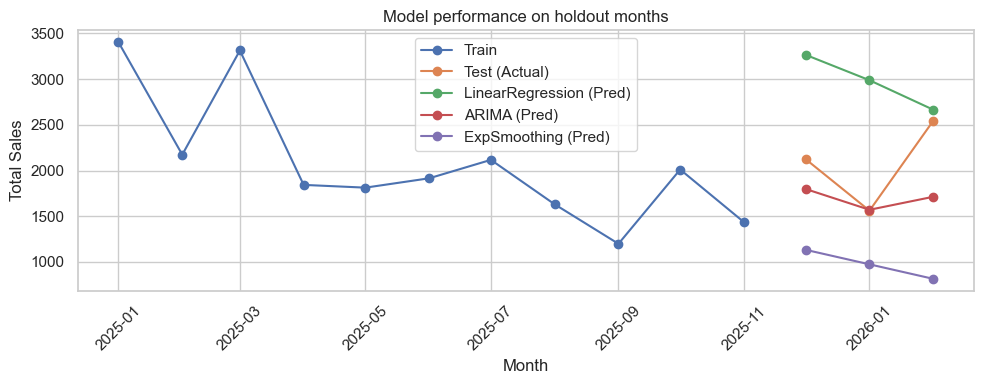

Best model by RMSE on test: ARIMA


,LinearRegression,ARIMA,ExpSmoothing
2026-03-01,2875.054667,1623.729903,656.214829
2026-04-01,2579.164591,1679.617403,497.494626
2026-05-01,2347.902903,1644.598576,338.774422
2026-06-01,2195.103927,1666.541197,180.054219
2026-07-01,2113.577965,1652.792061,21.334016
2026-08-01,2077.037776,1661.407201,-137.386187


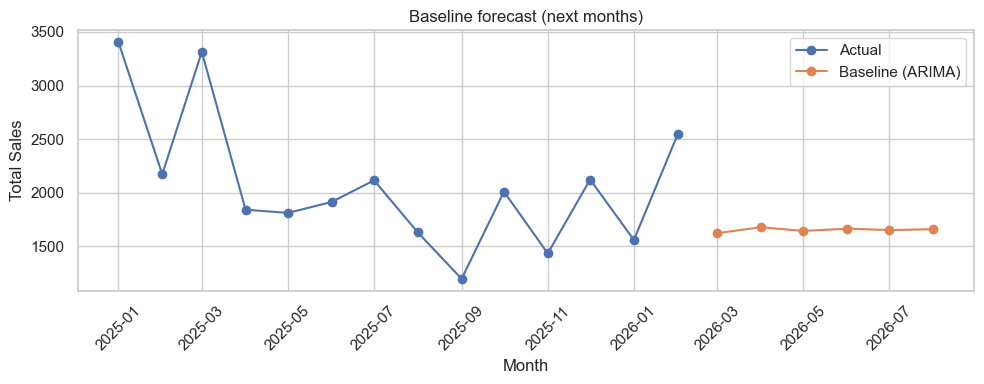

In [ ]:
# Forecast using multiple approaches: Linear Regression, ARIMA, Exponential Smoothing

def _forecast_metrics(y_true: pd.Series, y_pred: pd.Series) -> dict:
    y_true, y_pred = y_true.align(y_pred, join='inner')
    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mape = float((np.abs((y_true - y_pred) / y_true.replace(0, np.nan))).mean() * 100)
    return {'MAE': float(mae), 'RMSE': float(rmse), 'MAPE_%': float(mape)}

def _plot_test_predictions(title: str, y_train: pd.Series, y_test: pd.Series, preds):
    plt.figure(figsize=(10, 4))
    plt.plot(y_train.index, y_train.values, label='Train', marker='o')
    plt.plot(y_test.index, y_test.values, label='Test (Actual)', marker='o')
    for name, s in preds.items():
        s = s.reindex(y_test.index)
        plt.plot(s.index, s.values, label=f'{name} (Pred)', marker='o')
    plt.title(title)
    plt.xlabel('Month')
    plt.ylabel('Total Sales')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- 1) Linear Regression ---
lr_cols = ['t', 'month_sin', 'month_cos']
lr = LinearRegression()
lr.fit(train_X[lr_cols], train_y.values)

lr_test_pred = pd.Series(lr.predict(test_X[lr_cols]), index=test_y.index, name='LinearRegression')
lr_future_pred = pd.Series(lr.predict(future_X[lr_cols]), index=future_index, name='LinearRegression')

# --- 2) ARIMA / SARIMA (statsmodels) ---
warnings.filterwarnings('ignore')

def _fit_arima(y_train: pd.Series):
    if len(y_train) >= 24:
        # SARIMA with yearly seasonality (12) if enough data
        best = None
        for order in [(1, 1, 1), (2, 1, 1), (1, 1, 2)]:
            for seasonal_order in [(1, 0, 1, 12), (0, 1, 1, 12)]:
                try:
                    m = SARIMAX(y_train, order=order, seasonal_order=seasonal_order, enforce_stationarity=False, enforce_invertibility=False)
                    r = m.fit(disp=False)
                    score = float(r.aic)
                    if best is None or score < best[0]:
                        best = (score, r, order, seasonal_order)
                except Exception:
                    continue
        if best is not None:
            _, res, order, seasonal_order = best
            print(f"ARIMA selected: SARIMAX order={order}, seasonal_order={seasonal_order} (AIC={best[0]:.2f})")
            return res

    # Non-seasonal ARIMA fallback
    best = None
    for order in [(1, 1, 1), (2, 1, 1), (1, 1, 2), (0, 1, 1)]:
        try:
            m = ARIMA(y_train, order=order)
            r = m.fit()
            score = float(r.aic)
            if best is None or score < best[0]:
                best = (score, r, order)
        except Exception:
            continue
    if best is None:
        raise RuntimeError('ARIMA fitting failed for all candidate orders.')
    print(f"ARIMA selected: order={best[2]} (AIC={best[0]:.2f})")
    return best[1]

arima_res = _fit_arima(train_y)
arima_steps = len(test_y) + FORECAST_HORIZON

if hasattr(arima_res, 'get_forecast'):
    arima_fc = arima_res.get_forecast(steps=arima_steps).predicted_mean
else:
    arima_fc = arima_res.forecast(steps=arima_steps)

arima_fc_index = pd.date_range(start=train_y.index.max() + pd.offsets.MonthBegin(1), periods=arima_steps, freq='MS')
arima_fc = pd.Series(np.asarray(arima_fc), index=arima_fc_index, name='ARIMA')
arima_test_pred = arima_fc.iloc[:len(test_y)].reindex(test_y.index)
arima_future_pred = arima_fc.iloc[len(test_y):]

# --- 3) Exponential Smoothing (Holt-Winters) ---
seasonal = 'add' if len(train_y) >= 24 else None
trend = 'add' if len(train_y) >= 6 else None
seasonal_periods = 12 if seasonal is not None else None

es_model = ExponentialSmoothing(train_y, trend=trend, seasonal=seasonal, seasonal_periods=seasonal_periods)
es_fit = es_model.fit(optimized=True)
es_fc = es_fit.forecast(steps=len(test_y) + FORECAST_HORIZON)

es_fc_index = pd.date_range(start=train_y.index.max() + pd.offsets.MonthBegin(1), periods=len(test_y) + FORECAST_HORIZON, freq='MS')
es_fc = pd.Series(np.asarray(es_fc), index=es_fc_index, name='ExpSmoothing')
es_test_pred = es_fc.iloc[:len(test_y)].reindex(test_y.index)
es_future_pred = es_fc.iloc[len(test_y):]

# --- Evaluate on the test set ---
test_preds = {
    'LinearRegression': lr_test_pred,
    'ARIMA': arima_test_pred,
    'ExpSmoothing': es_test_pred,}

metrics_rows = []
for name, pred in test_preds.items():
    row = {'Model': name}
    row.update(_forecast_metrics(test_y, pred))
    metrics_rows.append(row)

metrics_df = pd.DataFrame(metrics_rows).sort_values('RMSE')
display(metrics_df)

_plot_test_predictions('Model performance on holdout months', train_y, test_y, test_preds)

# --- Future forecast table ---
future_forecasts = pd.DataFrame({
    'LinearRegression': lr_future_pred,
    'ARIMA': arima_future_pred.reindex(future_index),
    'ExpSmoothing': es_future_pred.reindex(future_index),
})

best_model = metrics_df.iloc[0]['Model']
baseline_forecast = future_forecasts[best_model].rename('Baseline')

print(f"Best model by RMSE on test: {best_model}")
display(future_forecasts)

plt.figure(figsize=(10, 4))
plt.plot(y.index, y.values, label='Actual', marker='o')
plt.plot(baseline_forecast.index, baseline_forecast.values, label=f'Baseline ({best_model})', marker='o')
plt.title('Baseline forecast (next months)')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


## Scenario Simulation & Future Planning

Beyond forecasting future sales based on historical data, scenario simulations allow us to test how different business strategies might impact future revenue.

Simulation 1: What if marketing increases sales volume?
Simulation 2: What if prices increase?
Simulation 3: What if demand drops due to market conditions?

The following scenarios model potential business outcomes.

,Baseline,Marketing +10%,Price +5%,Demand -8%
2026-03-01,1623.729903,1786.102893,1704.916398,1493.831511
2026-04-01,1679.617403,1847.579143,1763.598273,1545.248011
2026-05-01,1644.598576,1809.058434,1726.828505,1513.030690
2026-06-01,1666.541197,1833.195317,1749.868257,1533.217901
2026-07-01,1652.792061,1818.071267,1735.431664,1520.568696
2026-08-01,1661.407201,1827.547921,1744.477561,1528.494624


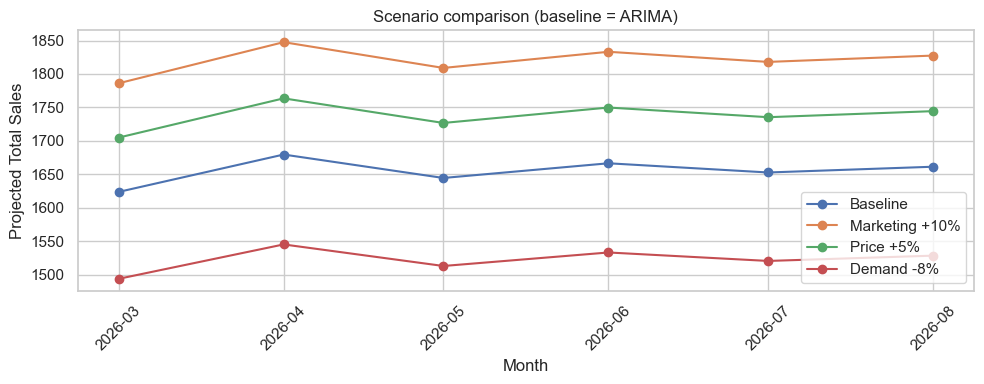

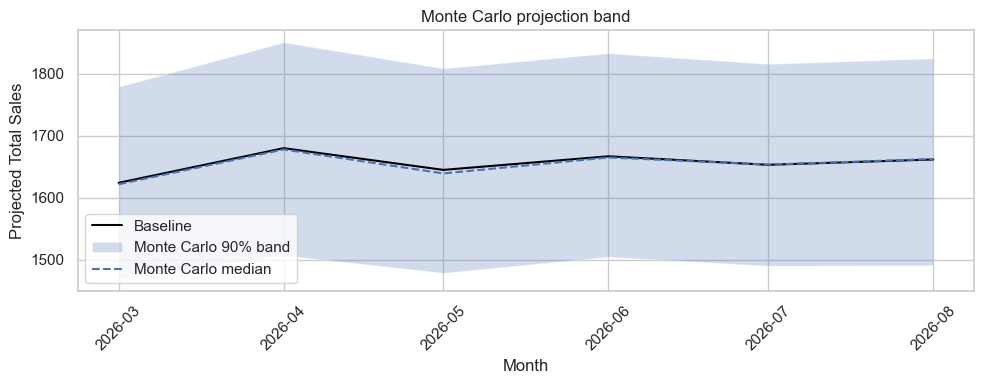

In [ ]:
# Scenario simulation based on the baseline forecast

BASELINE_MODEL = None  

if 'metrics_df' not in globals() or 'future_forecasts' not in globals():
    raise RuntimeError('Run the forecasting section above first.')

chosen_model = BASELINE_MODEL or metrics_df.iloc[0]['Model']
baseline = future_forecasts[chosen_model].rename('Baseline')

scenarios = pd.DataFrame({
    'Baseline': baseline,
    'Marketing +10%': baseline * 1.10,
    'Price +5%': baseline * 1.05,
    'Demand -8%': baseline * 0.92,
})

display(scenarios)

plt.figure(figsize=(10, 4))
for col in scenarios.columns:
    plt.plot(scenarios.index, scenarios[col].values, marker='o', label=col)
plt.title(f'Scenario comparison (baseline = {chosen_model})')
plt.xlabel('Month')
plt.ylabel('Projected Total Sales')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Monte Carlo simulation around baseline (e.g., +/- 10% demand noise)
rng = np.random.default_rng(42)
N_SIM = 2000
noise_std = 0.06  # 6% standard deviation
sim = baseline.values.reshape(1, -1) * (1.0 + rng.normal(0.0, noise_std, size=(N_SIM, len(baseline))))

sim_p05 = np.percentile(sim, 5, axis=0)
sim_p50 = np.percentile(sim, 50, axis=0)
sim_p95 = np.percentile(sim, 95, axis=0)

mc_df = pd.DataFrame({
    'P05': sim_p05,
    'P50': sim_p50,
    'P95': sim_p95,
}, index=baseline.index)

plt.figure(figsize=(10, 4))
plt.plot(baseline.index, baseline.values, label='Baseline', color='black')
plt.fill_between(mc_df.index, mc_df['P05'].values, mc_df['P95'].values, alpha=0.25, label='Monte Carlo 90% band')
plt.plot(mc_df.index, mc_df['P50'].values, linestyle='--', label='Monte Carlo median')
plt.title('Monte Carlo projection band')
plt.xlabel('Month')
plt.ylabel('Projected Total Sales')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In [58]:
# Export forecasts and scenario outputs for the dashboard (CSV)

OUTPUT_DIR = Path('..') / 'Output' 
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if 'future_forecasts' in globals():
    future_forecasts.to_csv(OUTPUT_DIR / 'future_forecasts_all_models.csv', index_label='Month')

if 'metrics_df' in globals():
    metrics_df.to_csv(OUTPUT_DIR / 'forecast_metrics.csv', index=False)

if 'scenarios' in globals():
    scenarios.to_csv(OUTPUT_DIR / 'scenario_forecasts.csv', index_label='Month')

if 'mc_df' in globals():
    mc_df.to_csv(OUTPUT_DIR / 'monte_carlo_band.csv', index_label='Month')

print(f"Wrote outputs to: {OUTPUT_DIR.resolve()}")
print('Files:')
for p in sorted(OUTPUT_DIR.glob('*.csv')):
    print(' -', p.name)


Wrote outputs to: C:\Users\65967\OneDrive - Singapore Management University\Documents\GitHub\Koryori_Hayashi\Dashboard\Output
Files:
 - forecast_metrics.csv
 - future_forecasts_all_models.csv
 - monte_carlo_band.csv
 - scenario_forecasts.csv
